## SOCIAL NETWORK ANALYSIS PROJECT - Forrest Gump

In this project I will analyze the graph of "Forrest Gump". In this network, each node represents a character, while each edge represents a shared scene between two characters. Since some pairs of characters appear together more frequently than others, the graph is weighted, with edge weights indicating the number of same-scene appearances. The network is undirected because the relationship is based on co-presence rather than direction or influence. Our aim is to understand week by week the underlying structure of the graph including the number of nodes and edges, average degree, density, connected components, clustering coefficients, and centrality measures. By examining these measures, we can identify which characters are most connected, which groups of characters are closely linked, and how the overall network changes over time. Through this analysis, the project highlights how Forrest functions as the central character of the network, connecting many different groups and storylines. Overall, the graph provides a clear way to explore the narrative structure of Forrest Gump and better understand how character relationships shape the movie. This project also shows how graph theory can be used as a useful tool for analyzing movies and narrative, providing a visual and mathematical way to explore relationships between characters. Overall, this analysis gives a clearer understanding of the structure of Forrest Gump and demonstrates how character interactions shape the movie’s emotional and narrative development.

In [ ]:
from collections import defaultdict, deque, Counter
from itertools import combinations
from IPython.display import Image, display
import random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## **WEEK 1**


## Pick a social network among the one proposed on my.luiss and implement it in Python.

In [ ]:
nodes_path = "nodes.csv"
edges_path = "edges.csv"
gprops_path= "gprops.csv"

nodes_df = pd.read_csv(nodes_path)
edges_df = pd.read_csv(edges_path)
gprops_df = pd.read_csv(gprops_path, sep=';')

print(nodes_df.head())
print(edges_df.head())
columns_nodes = nodes_df.columns
print(columns_nodes)
columns_edges = edges_df.columns
print(columns_edges)

   # index          label   movie_id
0        0  ABBIE HOFFMAN        316
1        1   AGING HIPPIE        316
2        2      ANCHORMAN        316
3        3      ANNOUNCER        316
4        4    ANOTHER DAY        316
   # source   target   label   movie_id   weight
0         0       41   66951        316        1
1         0       73   66949        316        1
2         0       35   66930        316        1
3         0       39   66941        316        1
4         0       40   66936        316        1
Index(['# index', ' label', ' movie_id'], dtype='object')
Index(['# source', ' target', ' label', ' movie_id', ' weight'], dtype='object')


We retrieve the csv of edges and nodes and the name of the columns.

## Draw the graph

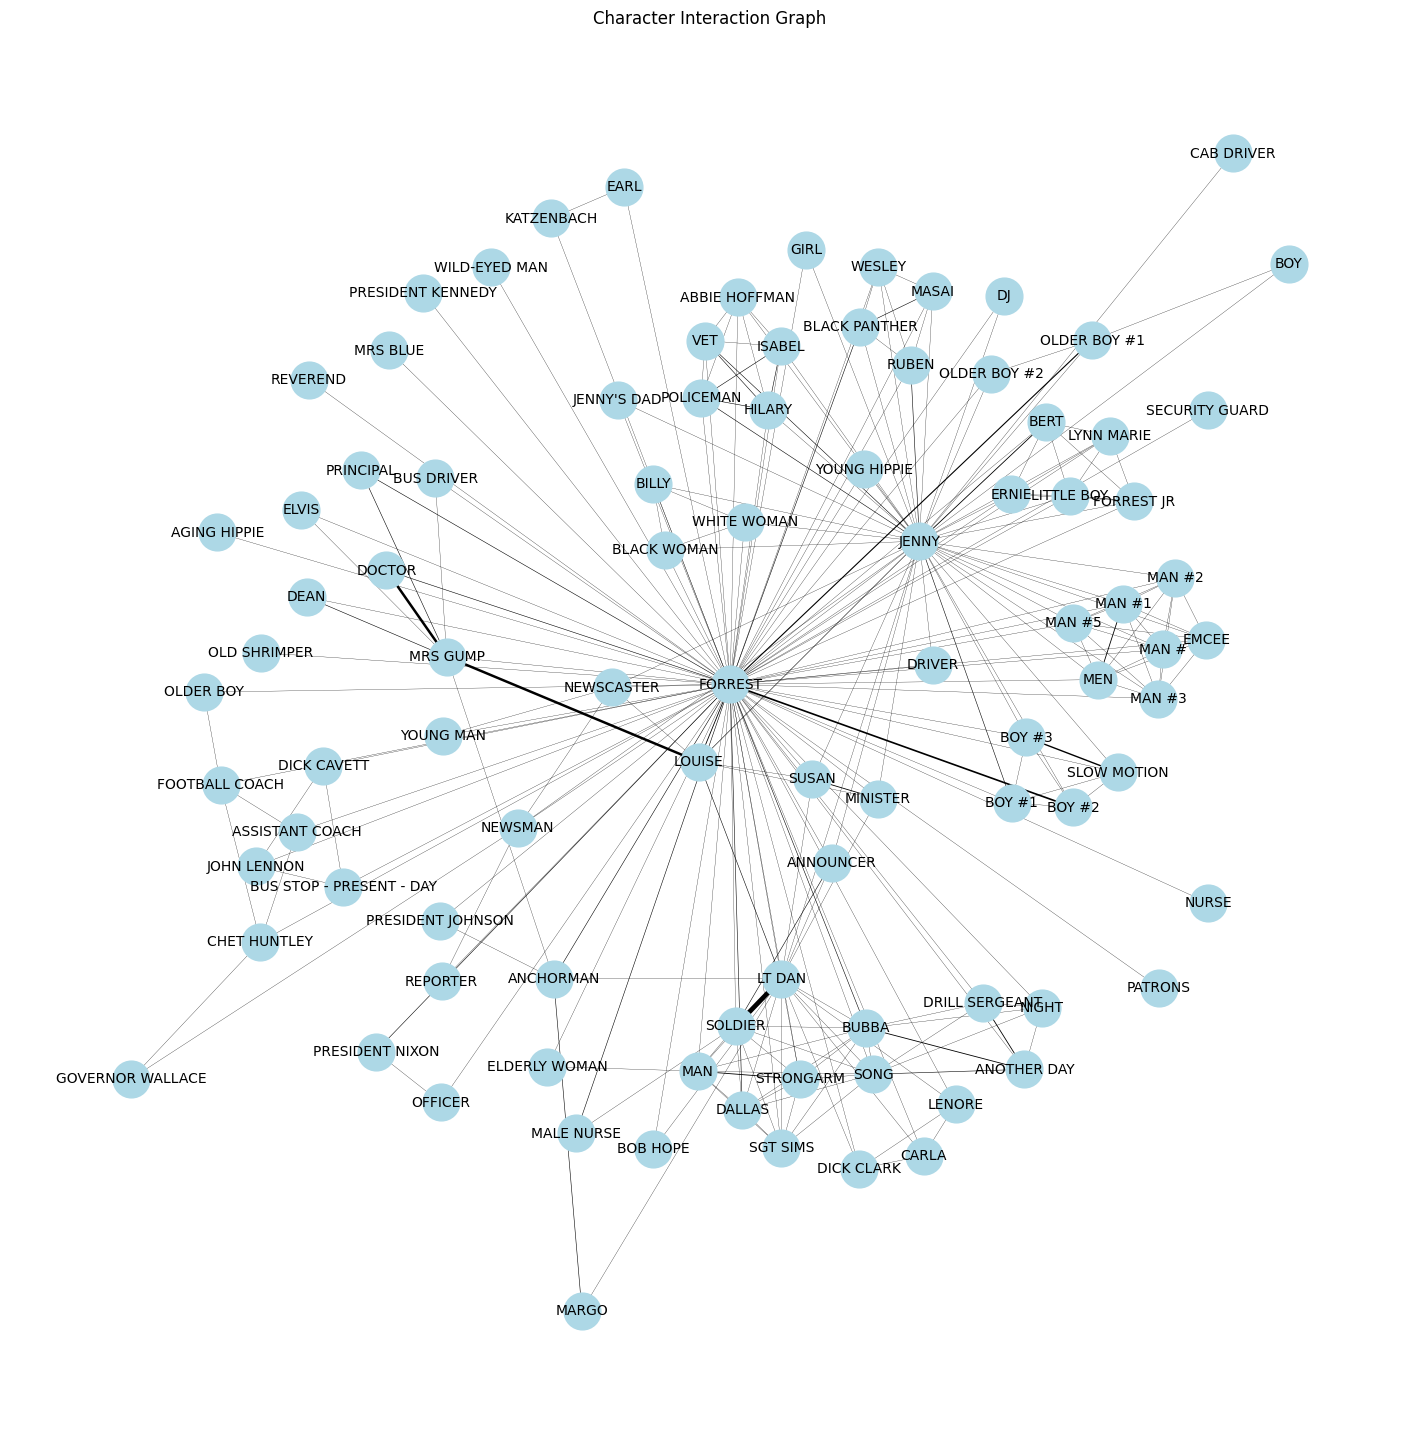

In [ ]:
#we draw the graph using networkx and matplotlib
#the weight will be represented by the thickness of the edge, which is given by the number of interactions between the characters
G = nx.from_pandas_edgelist(edges_df, '# source', ' target', ' weight')
labels = {row['# index']: row[' label'] for label, row in nodes_df.iterrows()}
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, seed=42)  # positions for all nodes
nx.draw(G, pos, with_labels=True, labels=labels, node_size=700, node_color='lightblue', font_size=10, width=edges_df[' weight'] / 5)
plt.title('Character Interaction Graph')
plt.show()

The graph is visualized using a spring layout, which places strongly connected nodes closer together and less connected nodes farther apart. This layout helps highlight the structure of the network and the relative centrality of characters. The node “35”, corresponding to Forrest, appears in the center of the network, reflecting his role as the main character who interacts with many others.

## Compute the number of nodes,edges, average degree and the density. Comment.

In [ ]:
#number of nodes and edges without using function of networkx
number_of_nodes = len(G.nodes())
number_of_edges = len(G.edges())
print("Number of nodes:", number_of_nodes)
print("Number of edges:", number_of_edges)
#average degree
degrees = dict(G.degree())
avg_degree = sum(degrees.values()) / number_of_nodes
print("Average degree:", avg_degree)
#density
density = (2 * number_of_edges) / (number_of_nodes * (number_of_nodes - 1))
print("Density:", density)
#highest degree node with label of the character and its degree
highest_degree_node = max(degrees, key=degrees.get)
character_name = nodes_df.loc[nodes_df['# index'] == highest_degree_node, ' label'].values[0] #the label column contains the character's names
print("Highest degree node:", highest_degree_node, character_name, "with degree", degrees[highest_degree_node])

print("Character name:", character_name)
#highest weighted edge
highest_weighted_edge = max(G.edges(data=True), key=lambda x: x[2][' weight'])
name1 = nodes_df.loc[nodes_df['# index'] == highest_weighted_edge[0], ' label'].values[0]
name2 = nodes_df.loc[nodes_df['# index'] == highest_weighted_edge[1], ' label'].values[0]
print("Highest weighted edge:", name1, "-", name2, "with weight", highest_weighted_edge[2][' weight'])

Number of nodes: 94
Number of edges: 271
Average degree: 5.76595744680851
Density: 0.06199954243880119
Highest degree node: 35 FORREST with degree 89
Character name: FORREST
Highest weighted edge: JENNY - FORREST with weight 17


The network consists of 94 nodes, corresponding to the characters in the movie, and 271 edges, representing interactions between pairs of characters.
The density of the network is approximately 0.062, which is relatively low compared to the maximum possible number of edges, indicating that the graph is sparse. This means that only a small fraction of all possible character interactions actually occurs.
The average degree is about 5.77, showing that each character interacts, on average, with around six other characters.
The character with the highest degree is Forrest (node 35), with 89 connections, confirming his central role in the story.
The strongest interaction (highest-weighted edge) occurs between Forrest and Jenny, with a weight of 17, indicating that they share the highest number of scenes among all character pairs.

## **WEEK 2**

In Week 2, we analyze clustering on the largest connected component (LCC), since clustering measures are more meaningful on a connected graph. The goal is to compute the local clustering coefficient of each node and the average clustering of the network.

In [ ]:
def clustering_per_node_manual(H):
    C = {}
    for v in H.nodes():
        neigh = list(H.neighbors(v))
        k = len(neigh)
        if k < 2:
            C[v] = 0.0
            continue

        links = 0
        for i in range(k):
            for j in range(i + 1, k):
                if H.has_edge(neigh[i], neigh[j]):
                    links += 1

        possible = k * (k - 1) / 2
        C[v] = links / possible
    return C

def average_clustering_manual(H):
    C = clustering_per_node_manual(H)
    return sum(C.values()) / H.number_of_nodes()

In [ ]:
largest_cc = max(nx.connected_components(G), key=len)
H = G.subgraph(largest_cc).copy()

print("H has ", H.number_of_nodes(), "nodes &", H.number_of_edges(), "edges")

H has  94 nodes & 271 edges


### Manual clustering coefficient

For each node \(v\), the local clustering coefficient measures how connected its neighbors are. It is computed as the ratio between the number of links among neighbors and the maximum possible number of such links. If a node has degree smaller than 2, its clustering is set to 0.


In [ ]:
C_manual = clustering_per_node_manual(H)
avgC_manual = average_clustering_manual(H)

C_nx = nx.clustering(H)
avgC_nx = nx.average_clustering(H)
transitivity_nx = nx.transitivity(H)

print("Manual average clustering (LCC):", avgC_manual)
print("NetworkX average clustering (LCC):", avgC_nx)
print("NetworkX transitivity (LCC):", transitivity_nx)

max_abs_diff = max(abs(C_manual[v] - C_nx[v]) for v in H.nodes())
print("Max |manual - networkx| over nodes:", max_abs_diff)

Manual average clustering (LCC): 0.8002425574908809
NetworkX average clustering (LCC): 0.8002425574908809
NetworkX transitivity (LCC): 0.1918081918081918
Max |manual - networkx| over nodes: 0.0


### Validation and transitivity

After computing clustering manually, I compare the results with `networkx.clustering()` and `networkx.average_clustering()` to verify correctness. I also compute transitivity, a global clustering measure based on triangles and connected triples, to compare local and global cohesion.

In [ ]:
top10 = sorted(C_manual.items(), key=lambda x: x[1], reverse=True)[:10]

nodes_df.columns = nodes_df.columns.astype(str).str.strip()
id_col = "# index" if "# index" in nodes_df.columns else "index"
label_col = "label" if "label" in nodes_df.columns else "Label"
id_to_label = dict(zip(nodes_df[id_col], nodes_df[label_col]))

print("\nTop 10 nodes by clustering (manual):")
for node, c in top10:
    name = id_to_label.get(node, str(node))
    print(f"{node} ({name}) -> {c:.4f}")


Top 10 nodes by clustering (manual):
0 (ABBIE HOFFMAN) -> 1.0000
73 (POLICEMAN) -> 1.0000
39 (HILARY) -> 1.0000
40 (ISABEL) -> 1.0000
88 (VET) -> 1.0000
57 (MARGO) -> 1.0000
74 (PRESIDENT JOHNSON) -> 1.0000
4 (ANOTHER DAY) -> 1.0000
65 (NIGHT) -> 1.0000
27 (DRILL SERGEANT) -> 1.0000


### Top clustered nodes

To better interpret the results, I rank the nodes by local clustering coefficient and show the top 10. Nodes with high clustering belong to tightly connected local groups, while more central or bridging characters may have lower clustering because their neighbors are not all connected.


# **WEEK 3**

In this section we analyze clustering patterns on the largest connected component \(H\), reusing the node-level clustering coefficients \(C(v)\) computed in Week 2.

We first build the complementary cumulative distribution (CCDF) of \(C(v)\), the fraction of nodes with clustering above a threshold \(x\). Then, for each node \(v\), we compute the average clustering of its neighbors $ \overline{C}_{N(v)} $   and its CCDF.

Finally, we compare the two distributions.


### Compute the average clustering of each node’s neighbors

In [ ]:
C = C_nx
clust_values = np.array(list(C.values()), dtype=float)

# Average clustering of neighbors for each node
nbr_avg_clust = {}
for v in H.nodes():
    nbrs = list(H.neighbors(v))
    if len(nbrs) == 0:
        nbr_avg_clust[v] = 0.0
    else:
        nbr_avg_clust[v] = float(np.mean([C[u] for u in nbrs]))

nbr_avg_values = np.array(list(nbr_avg_clust.values()), dtype=float)

def ccdf(values):
    values = np.asarray(values, dtype=float)
    xs = np.sort(np.unique(values))
    ys = np.array([(values >= x).mean() for x in xs], dtype=float)
    return xs, ys

x1, y1 = ccdf(clust_values)
x2, y2 = ccdf(nbr_avg_values)

### Plot the CCDFs of clustering values

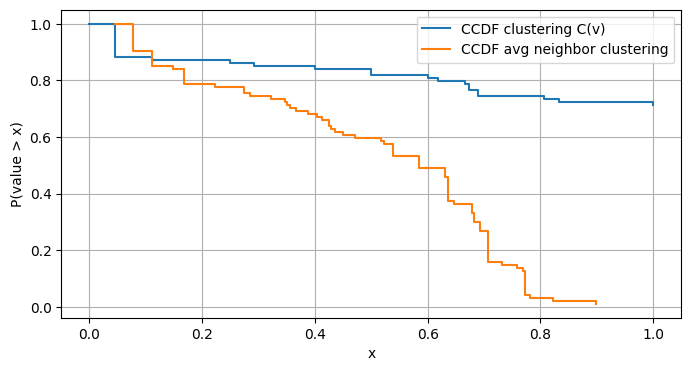

In [ ]:
plt.figure(figsize=(8,4))
plt.step(x1, y1, where="post", label="CCDF clustering C(v)")
plt.step(x2, y2, where="post", label="CCDF avg neighbor clustering")
plt.xlabel("x")
plt.ylabel("P(value > x)")
plt.legend()
plt.grid(True)
plt.show()

### Compare the mean clustering values

In [ ]:
print("Mean C(v):", clust_values.mean())
print("Mean avg-neighbor clustering:", nbr_avg_values.mean())

Mean C(v): 0.800242557490881
Mean avg-neighbor clustering: 0.48033898154902777


**Interpretation of the results**

The CCDF for $C(v)$ lies above the CCDF for $\overline{C}_{N(v)}$ across most thresholds, indicating that high node clustering is more frequent than high average neighbor clustering.

This is consistent with the means: $\mathbb{E}[C(v)] \approx 0.800$ versus $\mathbb{E}[\overline{C}_{N(v)}] \approx 0.480$. The neighbor-based curve drops faster and is near zero around $x \approx 0.85$, suggesting that extremely clustered neighborhoods are rare on average. Overall, the network shows strong local cohesion but unevenly distributed around nodes.

# **WEEK 5**

For week 5, we identified the most central nodes.

To achieve this task, we opted to use betweeness centrality and closeness centrality.

We chose betweeness since it identifies characters which act as connectors in the movie. It is particularly important in Forrest Gump since it is a story which spans several locations and periods of time.

We chose closeness centrality since it measures the velocity of spread of information. It identifies characters who are consistent throught the movie.

### Centralities = Betweeness and Closeness

In [ ]:
betweenness = nx.betweenness_centrality(H)
closeness = nx.closeness_centrality(H)
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]

### Most central nodes

In [ ]:
print("top 10 nodes by betweenness:")
for node, centrality_value in top_betweenness:
    name = id_to_label.get(node, str(node))
    print(f"{node} ({name}): {centrality_value}")

top 10 nodes by betweenness:
35 (FORREST): 0.8073398784478726
41 (JENNY): 0.1361890291413433
48 (LT DAN): 0.028054386785102064
64 (NEWSMAN): 0.013016206950288305
20 (CHET HUNTLEY): 0.00868396446937821
2 (ANCHORMAN): 0.007534673523453334
70 (OLDER BOY #1): 0.005006233442418575
62 (MRS GUMP): 0.002805049088359046
15 (BUBBA): 0.0015778401122019637
85 (SONG): 0.0015778401122019637


In [ ]:
print("top 10 nodes by closeness:")
for node, centrality_value in top_closeness:
    name = id_to_label.get(node, str(node))
    print(f"{node} ({name}): {centrality_value}")

top 10 nodes by closeness:
35 (FORREST): 0.9587628865979382
41 (JENNY): 0.6595744680851063
48 (LT DAN): 0.5535714285714286
15 (BUBBA): 0.5224719101123596
85 (SONG): 0.5224719101123596
84 (SOLDIER): 0.5195530726256983
51 (MAN): 0.5166666666666667
32 (EMCEE): 0.5166666666666667
52 (MAN #): 0.5166666666666667
53 (MAN #1): 0.5166666666666667


**Interpretation of the results**

According to both measures, among the most central components we find Forrest, Jenny and Lt. Dan.

As expected, the most central component is Forrest, the main character. Other two consisently central characters are Jenny and Lt. Dan. They also play pivotal roles in the movie, appearing in multiple periods of time and meeting Forrest in many different locations.

# **WEEK 6**

In this week, the network is analyzed using two community detection algorithms: bridge removal and label propagation. Before applying these methods, the graph is preprocessed by removing self-loops and restricting the analysis to the largest connected component, ensuring a consistent and meaningful structure.

The two algorithms follow different principles. Bridge removal iteratively removes edges with the highest betweenness centrality, progressively revealing community structure. In contrast, label propagation assigns labels to nodes and updates them based on their neighbors, leading to a fast but potentially unstable partition.

To evaluate and compare the results, we rely primarily on modularity, which is the standard metric used to assess the quality of community partitions. Additional aspects such as interpretability, stability, and structural coherence are also considered in the analysis.

### Undirected and Unweighted graph, delete loops and work on largest connected component

In [ ]:
# Identify source and target columns in the edge list
source_col = [c for c in edges_df.columns if "source" in c.lower()][0]
target_col = [c for c in edges_df.columns if "target" in c.lower()][0]

# Remove self-loops
edges_clean = edges_df[edges_df[source_col] != edges_df[target_col]].copy()

# Build an undirected and unweighted graph using an adjacency list
graph = defaultdict(set)
for _, row in edges_clean.iterrows():
    u = row[source_col]
    v = row[target_col]
    graph[u].add(v)
    graph[v].add(u)

# Function to find all connected components using BFS
def connected_components(graph):
    visited = set()
    components = []
    for node in graph:
        if node not in visited:
            queue = deque([node])
            component = set()
            while queue:
                current = queue.popleft()
                if current not in visited:
                    visited.add(current)
                    component.add(current)
                    for neighbor in graph[current]:
                        if neighbor not in visited:
                            queue.append(neighbor)
            components.append(component)
    return components

# Find the largest connected component
components = connected_components(graph)
largest_cc = max(components, key=len)

# Keep only the nodes belonging to the largest connected component
graph_lcc = {node: graph[node] & largest_cc for node in largest_cc}

print("Original number of edges:", len(edges_df))
print("Number of edges after removing self-loops:", len(edges_clean))
print("Number of connected components:", len(components))
print("Nodes in the largest connected component:", len(graph_lcc))
print("Edges in the largest connected component:", sum(len(neigh) for neigh in graph_lcc.values()) // 2)

Original number of edges: 271
Number of edges after removing self-loops: 271
Number of connected components: 1
Nodes in the largest connected component: 94
Edges in the largest connected component: 271


### Bridge Removal

In [ ]:
random.seed(42)

# Make a copy of the preprocessed graph
original_graph = {node: set(neigh) for node, neigh in graph_lcc.items()}

# Connected components
def connected_components(graph):
    visited = set()
    components = []
    for node in graph:
        if node not in visited:
            queue = deque([node])
            component = set()
            while queue:
                current = queue.popleft()
                if current not in visited:
                    visited.add(current)
                    component.add(current)
                    for neighbor in graph[current]:
                        if neighbor not in visited:
                            queue.append(neighbor)
            components.append(component)
    return components

# Number of edges in an undirected graph
def count_edges(graph):
    return sum(len(neigh) for neigh in graph.values()) // 2

# Modularity for undirected, unweighted graph. Partition is evaluated on the original graph
def compute_modularity(graph, partition):
    m = count_edges(graph)
    if m == 0:
        return 0
    degrees = {node: len(graph[node]) for node in graph}
    Q = 0
    for community in partition:
        internal_edges = 0
        degree_sum = 0
        for node in community:
            degree_sum += degrees[node]
            for neighbor in graph[node]:
                if neighbor in community:
                    internal_edges += 1
        internal_edges = internal_edges / 2  # each internal edge counted twice
        Q += (internal_edges / m) - (degree_sum / (2 * m)) ** 2
    return Q

# Edge betweenness centrality, Brandes-style implementation for undirected graphs
def edge_betweenness(graph):
    betweenness = defaultdict(float)
    for s in graph:
        stack = []
        predecessors = defaultdict(list)
        sigma = dict.fromkeys(graph.keys(), 0.0)   # number of shortest paths
        distance = dict.fromkeys(graph.keys(), -1)
        sigma[s] = 1.0
        distance[s] = 0
        queue = deque([s])
        while queue:
            v = queue.popleft()
            stack.append(v)
            for w in graph[v]:
                if distance[w] < 0:
                    queue.append(w)
                    distance[w] = distance[v] + 1
                if distance[w] == distance[v] + 1:
                    sigma[w] += sigma[v]
                    predecessors[w].append(v)
        delta = dict.fromkeys(graph.keys(), 0.0)
        while stack:
            w = stack.pop()
            for v in predecessors[w]:
                if sigma[w] != 0:
                    contribution = (sigma[v] / sigma[w]) * (1 + delta[w])
                    edge = tuple(sorted((v, w)))
                    betweenness[edge] += contribution
                    delta[v] += contribution
    # Undirected graph: divide by 2
    for edge in betweenness:
        betweenness[edge] /= 2.0
    return betweenness

# BRIDGE REMOVAL
bridge_graph = {node: set(neigh) for node, neigh in original_graph.items()}
best_partition_bridge = connected_components(bridge_graph)
best_modularity_bridge = compute_modularity(original_graph, best_partition_bridge)
modularity_history = [best_modularity_bridge]
n_communities_history = [len(best_partition_bridge)]

while count_edges(bridge_graph) > 0:
    bet = edge_betweenness(bridge_graph)
    if not bet:
        break
    # Remove the edge with maximum betweenness
    edge_to_remove = max(bet, key=bet.get)
    u, v = edge_to_remove
    bridge_graph[u].remove(v)
    bridge_graph[v].remove(u)

    # Evaluate current partition
    current_partition = connected_components(bridge_graph)
    current_modularity = compute_modularity(original_graph, current_partition)
    modularity_history.append(current_modularity)
    n_communities_history.append(len(current_partition))
    if current_modularity > best_modularity_bridge:
        best_modularity_bridge = current_modularity
        best_partition_bridge = current_partition

print("BRIDGE REMOVAL")
print("Best number of communities:", len(best_partition_bridge))
print("Best modularity:", round(best_modularity_bridge, 4))
print("Community sizes:", [len(c) for c in best_partition_bridge])

# Convert the best bridge partition into a dictionary mapping nodes to communities
bridge_partition_dict = {}
for i, community in enumerate(best_partition_bridge):
    for node in community:
        bridge_partition_dict[node] = i

BRIDGE REMOVAL
Best number of communities: 35
Best modularity: 0.3232
Community sizes: [14, 1, 3, 1, 10, 5, 5, 3, 4, 5, 3, 4, 6, 3, 1, 1, 1, 2, 1, 1, 1, 3, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1]


### Label Propagation

In [ ]:
best_partition_label = None
best_modularity_label = -1
n_runs = 30
max_iter = 100
for run in range(n_runs):
    # Initialize one unique label per node
    labels = {node: i for i, node in enumerate(sorted(original_graph.keys()))}
    for _ in range(max_iter):
        changed = False
        nodes = sorted(original_graph.keys())
        for node in nodes:
            if len(original_graph[node]) == 0:
                continue
            neighbor_labels = [labels[neighbor] for neighbor in original_graph[node]]
            most_common = Counter(neighbor_labels).most_common()
            max_freq = most_common[0][1]
            candidate_labels = [lab for lab, freq in most_common if freq == max_freq]
            # Deterministic tie-breaking
            new_label = min(candidate_labels)
            if labels[node] != new_label:
                labels[node] = new_label
                changed = True
        if not changed:
            break
    # Build communities for this run
    label_partition_temp = defaultdict(set)
    for node, label in labels.items():
        label_partition_temp[label].add(node)
    current_partition_label = list(label_partition_temp.values())
    current_modularity_label = compute_modularity(original_graph, current_partition_label)
    # Keep the best run
    if current_modularity_label > best_modularity_label:
        best_modularity_label = current_modularity_label
        best_partition_label = current_partition_label

print("LABEL PROPAGATION")
print("Best number of communities:", len(best_partition_label))
print("Best modularity:", round(best_modularity_label, 4))
print("Community sizes:", [len(c) for c in best_partition_label])

# Convert the best label propagation partition into a dictionary mapping nodes to communities
label_partition_dict = {}
for i, community in enumerate(best_partition_label):
    for node in community:
        label_partition_dict[node] = i

LABEL PROPAGATION
Best number of communities: 7
Best modularity: 0.1823
Community sizes: [71, 5, 5, 3, 4, 3, 3]


In [ ]:
comparison_df = pd.DataFrame({
    "Method": ["Bridge removal", "Label propagation"],
    "Number of communities": [len(best_partition_bridge), len(best_partition_label)],
    "Modularity": [best_modularity_bridge, best_modularity_label]
})
comparison_df = comparison_df.sort_values(by="Modularity", ascending=False)
comparison_df

,Method,Number of communities,Modularity
0,Bridge removal,35,0.323151
1,Label propagation,7,0.182262


### Best Technique = Bridge Removal

In [ ]:
# Convert partitions to sets
partition_bridge = [set(c) for c in best_partition_bridge]
partition_label = [set(c) for c in best_partition_label]

# Summary statistics
summary_df = pd.DataFrame({
    "Method": ["Bridge removal", "Label propagation"],
    "Number of communities": [
        len(partition_bridge),
        len(partition_label)
    ],
    "Community sizes": [
        sorted([len(c) for c in partition_bridge], reverse=True),
        sorted([len(c) for c in partition_label], reverse=True)
    ],
    "Modularity": [
        nx.community.quality.modularity(G, partition_bridge),
        nx.community.quality.modularity(G, partition_label)
    ]
})
summary_df = summary_df.sort_values(by="Modularity", ascending=False).reset_index(drop=True)
summary_df

,Method,Number of communities,Community sizes,Modularity
0,Bridge removal,35,"[14, 10, 6, 5, 5, 5, 4, 4, 3, 3, 3, 3, 3, 2, 2...",0.323151
1,Label propagation,7,"[71, 5, 5, 4, 3, 3, 3]",0.182262


### Visualization of graph

In [ ]:
# Create a dictionary mapping nodes to communities
best_partition_dict = {}
for i, community in enumerate(best_partition_bridge):
    for node in community:
        best_partition_dict[node] = i

# Build undirected edge list without duplicates
edge_list = []
seen_edges = set()
for u in graph_lcc:
    for v in graph_lcc[u]:
        edge = tuple(sorted((str(u), str(v))))
        if edge not in seen_edges:
            seen_edges.add(edge)
            edge_list.append(edge)

# GEXF file
gexf_content = []
gexf_content.append('<?xml version="1.0" encoding="UTF-8"?>')
gexf_content.append('<gexf xmlns="http://www.gexf.net/1.2draft" version="1.2">')
gexf_content.append('  <graph mode="static" defaultedgetype="undirected">')

# Node attributes
gexf_content.append('    <attributes class="node">')
gexf_content.append('      <attribute id="0" title="community" type="integer"/>')
gexf_content.append('    </attributes>')

# Nodes
gexf_content.append('    <nodes>')
for node in best_partition_dict:
    node_id = str(node)
    community = best_partition_dict[node]
    gexf_content.append(f'      <node id="{node_id}" label="{node_id}">')
    gexf_content.append('        <attvalues>')
    gexf_content.append(f'          <attvalue for="0" value="{community}"/>')
    gexf_content.append('        </attvalues>')
    gexf_content.append('      </node>')
gexf_content.append('    </nodes>')

# Edges
gexf_content.append('    <edges>')
for i, (u, v) in enumerate(edge_list):
    gexf_content.append(f'      <edge id="{i}" source="{u}" target="{v}"/>')
gexf_content.append('    </edges>')
gexf_content.append('  </graph>')
gexf_content.append('</gexf>')

with open("bridge_removal_partition.gexf", "w", encoding="utf-8") as f:
    f.write("\n".join(gexf_content))

print("File exported successfully:  bridge_removal_partition.gexf")
print("Number of nodes:", len(best_partition_dict))
print("Number of edges:", len(edge_list))

File exported successfully:  bridge_removal_partition.gexf
Number of nodes: 94
Number of edges: 271


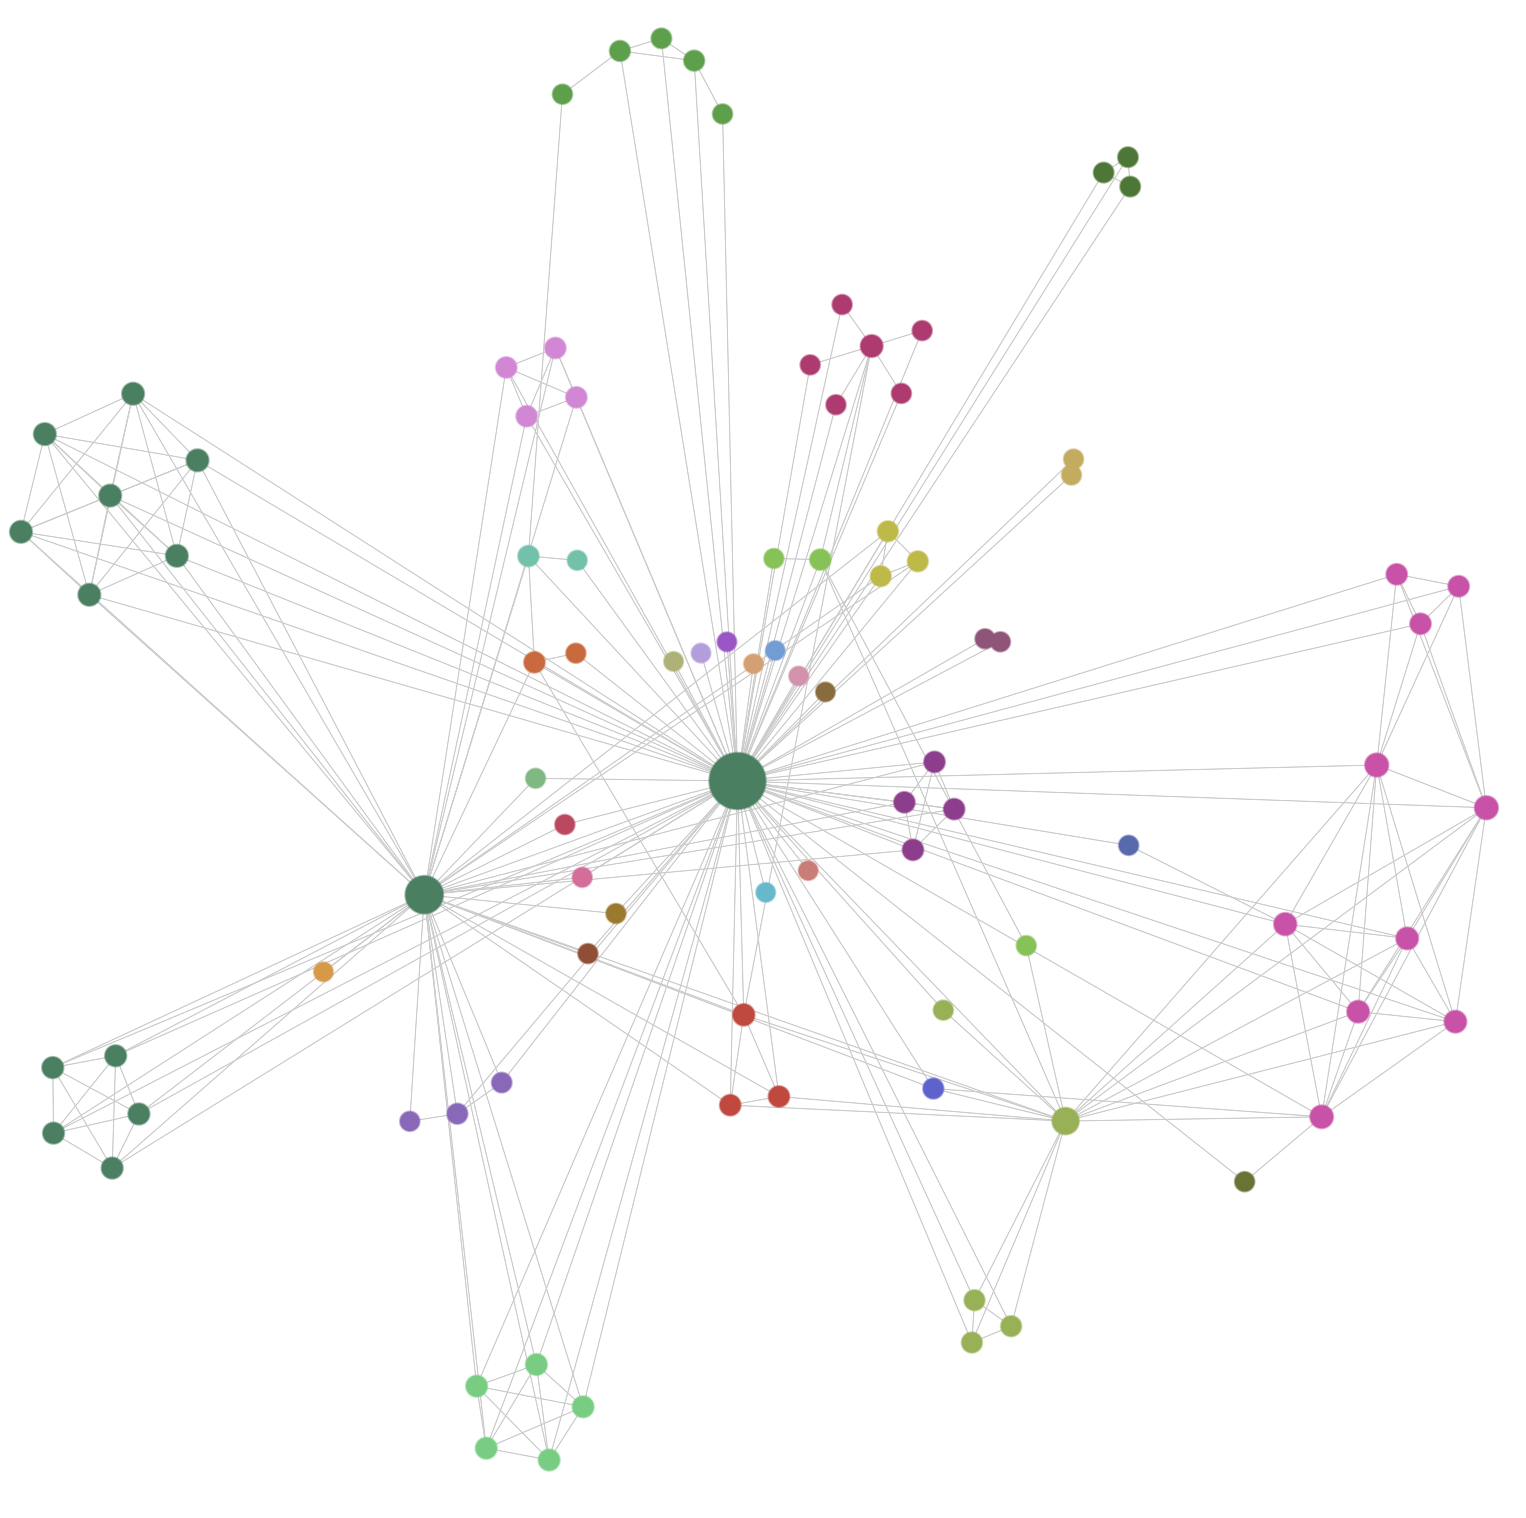

In [ ]:
display(Image("Gephi_Graph.png"))

Among the two methods, bridge removal provides the best partition.

This conclusion is primarily driven by modularity, which is the standard metric for assessing the quality of community structures. In our results, bridge removal achieves a significantly higher modularity (0.3232) than label propagation (0.1823), indicating a clearer separation between communities and a more meaningful organization of the network.

From a structural perspective, the partition obtained through bridge removal is also more interpretable. It reveals a finer-grained community structure, capturing smaller and more cohesive groups, whereas label propagation produces a coarser partition with a dominant large cluster, reducing the level of detail in the analysis.

Moreover, stability plays a key role in the comparison. Label propagation is inherently sensitive to initialization and may lead to different outcomes across runs, while bridge removal follows a deterministic procedure based on edge betweenness, ensuring more consistent results.

Finally, although bridge removal is computationally more demanding, this limitation is outweighed by the higher quality and interpretability of the resulting partition.

The Gephi visualization further supports this conclusion, as the communities identified by bridge removal appear more clearly separated and structurally coherent.

For these reasons, bridge removal is selected as the most appropriate method for this analysis.

# **WEEK 7**

This section focuses on link prediction on the largest connected component of the network, after treating the graph as undirected and unweighted and removing self-loops.

For each pair of unconnected nodes, we compute two topological similarity indices: Common Neighbors (CN) and Jaccard Index (JI). Since these measures operate on different scales, they are also rescaled to the [0,1] interval through min-max normalization. A third score is then constructed as the arithmetic mean of the normalized indices, in order to combine absolute overlap (CN) and relative overlap (JI).

Finally, candidate missing links are ranked according to each score, and the top-ranked pairs are compared to understand how the choice of the similarity measure affects the prediction results.

### Undirected and Unweighted graph, delete loops and work on largest connected component

In [ ]:
# Identify source and target columns in the edge list
source_col = [c for c in edges_df.columns if "source" in c.lower()][0]
target_col = [c for c in edges_df.columns if "target" in c.lower()][0]

# Remove self-loops
edges_clean = edges_df[edges_df[source_col] != edges_df[target_col]].copy()

# Build an undirected and unweighted graph using an adjacency list
graph = defaultdict(set)
for _, row in edges_clean.iterrows():
    u = row[source_col]
    v = row[target_col]
    graph[u].add(v)
    graph[v].add(u)

# Function to find all connected components using BFS
def connected_components(graph):
    visited = set()
    components = []
    for node in graph:
        if node not in visited:
            queue = deque([node])
            component = set()
            while queue:
                current = queue.popleft()
                if current not in visited:
                    visited.add(current)
                    component.add(current)
                    for neighbor in graph[current]:
                        if neighbor not in visited:
                            queue.append(neighbor)
            components.append(component)
    return components

# Find the largest connected component
components = connected_components(graph)
largest_cc = max(components, key=len)

# Keep only the nodes belonging to the largest connected component
graph_lcc = {node: graph[node] & largest_cc for node in largest_cc}

print("Original number of edges:", len(edges_df))
print("Number of edges after removing self-loops:", len(edges_clean))
print("Number of connected components:", len(components))
print("Nodes in the largest connected component:", len(graph_lcc))
print("Edges in the largest connected component:", sum(len(neigh) for neigh in graph_lcc.values()) // 2)

Original number of edges: 271
Number of edges after removing self-loops: 271
Number of connected components: 1
Nodes in the largest connected component: 94
Edges in the largest connected component: 271


### CN and JI

In [ ]:
# Convert adjacency-list representation into a NetworkX graph
G = nx.from_dict_of_lists(graph_lcc)


# Function to compute CN + one additional topological index for all missing links
def compute_missing_link_scores(G, second_index="JI"):
    """
    Compute Common Neighbors (CN) and one additional topological index
    for all missing links in an undirected graph.

    Parameters
    ----------
    G : networkx.Graph
        Undirected and unweighted graph.
    second_index : str
        Second index to compute. Options:
        "JI" = Jaccard Index
        "PA" = Preferential Attachment
        "AA" = Adamic-Adar
        "RA" = Resource Allocation

    Returns
    -------
    pandas.DataFrame
        DataFrame where each row is a missing link and columns are:
        node_1, node_2, CN, second index
    """

    nodes = list(G.nodes())
    missing_links = [(u, v) for u, v in combinations(nodes, 2) if not G.has_edge(u, v)]

    # Common Neighbors
    cn_scores = {(u, v): len(list(nx.common_neighbors(G, u, v))) for u, v in missing_links}

    # Second topological index
    if second_index == "JI":
        second_scores = {(u, v): score for u, v, score in nx.jaccard_coefficient(G, missing_links)}
    elif second_index == "PA":
        second_scores = {(u, v): score for u, v, score in nx.preferential_attachment(G, missing_links)}
    elif second_index == "AA":
        second_scores = {(u, v): score for u, v, score in nx.adamic_adar_index(G, missing_links)}
    elif second_index == "RA":
        second_scores = {(u, v): score for u, v, score in nx.resource_allocation_index(G, missing_links)}
    else:
        raise ValueError("second_index must be one of: 'JI', 'PA', 'AA', 'RA'")

    # Build the final DataFrame
    rows = []
    for u, v in missing_links:
        rows.append({
            "node_1": u,
            "node_2": v,
            "CN": cn_scores[(u, v)],
            second_index: second_scores[(u, v)]
        })
    scores_df = pd.DataFrame(rows)
    return scores_df

# Example: compute CN + JI
scores_df = compute_missing_link_scores(G, second_index="JI")
print("Number of missing links:", len(scores_df))
scores_df.head()

Number of missing links: 4100


,node_1,node_2,CN,JI
0,0,1,1,0.166667
1,0,2,1,0.100000
2,0,3,2,0.250000
3,0,4,1,0.100000
4,0,5,1,0.125000


### New column = sum of 2 indices

In [ ]:
# Min-Max normalization function
def min_max_scale(series):
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series(0.0, index=series.index)
    return (series - min_val) / (max_val - min_val)

# Normalize CN and JI
scores_df["CN_norm"] = min_max_scale(scores_df["CN"])
scores_df["JI_norm"] = min_max_scale(scores_df["JI"])

# Combined score (arithmetic mean)
scores_df["combined_score"] = (scores_df["CN_norm"] + scores_df["JI_norm"]) / 2

# Final dataframe check
print("Final dataframe structure:")
display(
    scores_df[
        ["node_1", "node_2", "CN", "JI", "CN_norm", "JI_norm", "combined_score"]
    ].head(10)
)

# Preview
scores_df.head()
scores_df_sorted = scores_df.sort_values(by="combined_score", ascending=False)
print("Top 10 predicted links (combined score):")
scores_df_sorted[["node_1", "node_2", "combined_score"]].head(10)

Final dataframe structure:


,node_1,node_2,CN,JI,CN_norm,JI_norm,combined_score
0,0,1,1,0.166667,0.333333,0.166667,0.250000
1,0,2,1,0.100000,0.333333,0.100000,0.216667
2,0,3,2,0.250000,0.666667,0.250000,0.458333
3,0,4,1,0.100000,0.333333,0.100000,0.216667
4,0,5,1,0.125000,0.333333,0.125000,0.229167
5,0,6,2,0.200000,0.666667,0.200000,0.433333
6,0,7,2,0.250000,0.666667,0.250000,0.458333
7,0,8,2,0.222222,0.666667,0.222222,0.444444
8,0,9,2,0.250000,0.666667,0.250000,0.458333
9,0,10,1,0.142857,0.333333,0.142857,0.238095


Top 10 predicted links (combined score):


,node_1,node_2,combined_score
1994,25,92,0.833333
2644,37,92,0.833333
2131,28,37,0.833333
2135,28,42,0.833333
2044,26,77,0.833333
1735,22,31,0.833333
2876,42,92,0.833333
1932,25,28,0.833333
1940,25,37,0.833333
1730,22,26,0.833333


### Missing links - 5/10 values

In [ ]:
# Top 10 links for each score
top_cn = scores_df.sort_values(by=["CN", "JI"], ascending=[False, False]).head(10)
top_ji = scores_df.sort_values(by=["JI", "CN"], ascending=[False, False]).head(10)
top_combined = scores_df.sort_values(
    by=["combined_score", "CN", "JI"],
    ascending=[False, False, False]).head(10)

print("Top 10 links by CN:")
display(top_cn[["node_1", "node_2", "CN"]])

print("\nTop 10 links by JI:")
display(top_ji[["node_1", "node_2", "JI"]])

print("\nTop 10 links by Combined Score:")
display(top_combined[["node_1", "node_2", "combined_score"]])

Top 10 links by CN:


,node_1,node_2,CN
317,3,60,3
343,3,87,3
3557,60,63,3
3671,63,87,3
305,3,47,3
221,2,47,3
281,3,21,3
339,3,82,3
342,3,86,3
3082,47,64,3



Top 10 links by JI:


,node_1,node_2,JI
1305,16,22,1.0
1309,16,26,1.0
1314,16,31,1.0
1358,16,77,1.0
1730,22,26,1.0
1735,22,31,1.0
1779,22,77,1.0
1932,25,28,1.0
1940,25,37,1.0
1944,25,42,1.0



Top 10 links by Combined Score:


,node_1,node_2,combined_score
1305,16,22,0.833333
1309,16,26,0.833333
1314,16,31,0.833333
1358,16,77,0.833333
1730,22,26,0.833333
1735,22,31,0.833333
1779,22,77,0.833333
1932,25,28,0.833333
1940,25,37,0.833333
1944,25,42,0.833333


The three rankings highlight different aspects of structural similarity in the network.

The Common Neighbors (CN) score mainly favors node pairs embedded in dense regions of the graph, since it rewards pairs sharing many common neighbors in absolute terms. As a result, it tends to prioritize links involving highly connected local structures.

The Jaccard Index (JI) provides a more selective perspective, because it normalizes the overlap by the total size of the two neighborhoods. For this reason, it favors node pairs whose neighborhoods are highly similar in relative terms, even when their degrees are not particularly large.

The combined score offers a more balanced ranking. By averaging the normalized values of CN and JI, it highlights node pairs that perform well both in terms of absolute common neighborhood and relative neighborhood overlap.

An additional element supporting this interpretation is that several node pairs appear in more than one top ranking, suggesting that these candidates are structurally strong under different similarity criteria. Overall, the combined score provides the most informative ranking, as it captures both local density and normalized similarity.

# **WEEK 9**

In this part, we use the undirected and unweighted largest connected component of the *Forrest Gump* character network as the reference graph. This choice is appropriate because the random graph models considered in this task are standard topological models, and the largest connected component allows a meaningful comparison of structural properties such as clustering, distance, and degree distribution.

In [ ]:
# Build the original undirected weighted graph from the dataset
G_full = nx.from_pandas_edgelist(
    edges_df,
    source='# source',
    target=' target',
    edge_attr=' weight',
    create_using=nx.Graph()
)

# Remove self-loops
G_full.remove_edges_from(nx.selfloop_edges(G_full))

# Convert to undirected and unweighted
G_ref = nx.Graph()
G_ref.add_edges_from(G_full.edges())

# Extract the largest connected component
largest_cc_nodes = max(nx.connected_components(G_ref), key=len)
G_ref = G_ref.subgraph(largest_cc_nodes).copy()

n = G_ref.number_of_nodes()
m = G_ref.number_of_edges()
avg_degree = sum(dict(G_ref.degree()).values()) / n
avg_clustering = nx.average_clustering(G_ref)
transitivity = nx.transitivity(G_ref)

print("Reference graph properties:")
print("Number of nodes:", n)
print("Number of edges:", m)
print("Average degree:", round(avg_degree, 4))
print("Average clustering:", round(avg_clustering, 4))
print("Transitivity:", round(transitivity, 4))

Reference graph properties:
Number of nodes: 94
Number of edges: 271
Average degree: 5.766
Average clustering: 0.8002
Transitivity: 0.1918


The reference graph has 94 nodes and average degree 5.766. It also shows high local clustering (0.8002) and non-negligible transitivity (0.1918), suggesting a network with both strong local cohesion and heterogeneous structural roles

## Model choice

We choose a variant of preferential attachment with triadic closure. This choice is appropriate because the *Forrest Gump* network combines two relevant features: a few highly central characters and a high level of local clustering. Preferential attachment captures the emergence of central hubs, while triadic closure helps reproduce the strong tendency of characters to appear in tightly connected groups.

In [ ]:
def preferential_attachment_with_triadic_closure(n, m, p_triangle=0.4, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    # Initial connected core
    G = nx.complete_graph(m + 1)
    for new_node in range(m + 1, n):
        targets = set()
        existing_nodes = list(G.nodes())

        while len(targets) < m:
            if len(targets) == 0 or random.random() > p_triangle:
                # Preferential attachment step
                degrees = np.array([G.degree(node) for node in existing_nodes], dtype=float)
                prob = degrees / degrees.sum()
                chosen = np.random.choice(existing_nodes, p=prob)
                targets.add(chosen)
            else:
                # Triadic closure step
                base = random.choice(list(targets))
                neighbors = list(G.neighbors(base))
                possible = [node for node in neighbors if node not in targets and node != new_node]

                if possible:
                    chosen = random.choice(possible)
                    targets.add(chosen)
                else:
                    degrees = np.array([G.degree(node) for node in existing_nodes], dtype=float)
                    prob = degrees / degrees.sum()
                    chosen = np.random.choice(existing_nodes, p=prob)
                    targets.add(chosen)

        for target in targets:
            G.add_edge(new_node, target)
    return G

In [ ]:
# Parameters chosen to match the reference graph
n_model = n
m_model = round(avg_degree / 2)   # approximately 3
p_triangle = 0.4                  # initial value, to be tuned

print("Chosen parameters:")
print("n =", n_model)
print("m =", m_model)
print("initial p_triangle =", p_triangle)

Chosen parameters:
n = 94
m = 3
initial p_triangle = 0.4


## Parameter tuning

We tune the triadic closure probability in order to reproduce the high clustering observed in the reference graph. Since the model is stochastic, we generate multiple realizations for each parameter value and compare their average clustering.

In [ ]:
# Candidate values for the triadic closure probability
p_values = [0.1, 0.3, 0.5, 0.7, 0.9]

target_clustering = avg_clustering
results = []

for p in p_values:
    clustering_values = []

    for seed in range(30):   # 30 realizations for each value
        G_sim = preferential_attachment_with_triadic_closure(
            n=n_model,
            m=m_model,
            p_triangle=p,
            seed=seed
        )
        clustering_values.append(nx.average_clustering(G_sim))

    mean_clustering = np.mean(clustering_values)
    results.append((p, mean_clustering, abs(mean_clustering - target_clustering)))

print("Tuning results:")
for p, mean_c, error in results:
    print(f"p_triangle = {p:.1f} | mean clustering = {mean_c:.4f} | error = {error:.4f}")

Tuning results:
p_triangle = 0.1 | mean clustering = 0.2100 | error = 0.5902
p_triangle = 0.3 | mean clustering = 0.2923 | error = 0.5079
p_triangle = 0.5 | mean clustering = 0.3697 | error = 0.4306
p_triangle = 0.7 | mean clustering = 0.4620 | error = 0.3383
p_triangle = 0.9 | mean clustering = 0.5538 | error = 0.2464


In [ ]:
best_p, best_clustering, best_error = min(results, key=lambda x: x[2])

print("\nBest parameter:")
print("p_triangle =", best_p)
print("mean clustering =", round(best_clustering, 4))
print("target clustering =", round(target_clustering, 4))


Best parameter:
p_triangle = 0.9
mean clustering = 0.5538
target clustering = 0.8002


The best value is $p_{\text{triangle}}= 0.9$. Although the model still underestimates clustering, the result confirms that strong triadic closure is necessary to reproduce the local cohesion of the reference graph.

## Final model comparison
Using the tuned parameters, we generate the final synthetic graph and compare its structural properties with those of the reference network.

In [ ]:
# Generate the final synthetic graph with the tuned parameter
G_final = preferential_attachment_with_triadic_closure(
    n=n_model,
    m=m_model,
    p_triangle=best_p,
    seed=42
)

# Compute properties of the final synthetic graph
n_final = G_final.number_of_nodes()
m_final = G_final.number_of_edges()
avg_degree_final = sum(dict(G_final.degree()).values()) / n_final
avg_clustering_final = nx.average_clustering(G_final)
transitivity_final = nx.transitivity(G_final)

print("Final synthetic graph properties:")
print("Number of nodes:", n_final)
print("Number of edges:", m_final)
print("Average degree:", round(avg_degree_final, 4))
print("Average clustering:", round(avg_clustering_final, 4))
print("Transitivity:", round(transitivity_final, 4))

Final synthetic graph properties:
Number of nodes: 94
Number of edges: 276
Average degree: 5.8723
Average clustering: 0.5493
Transitivity: 0.2276


In [ ]:
comparison_df = pd.DataFrame({
    "Property": ["Number of nodes", "Number of edges", "Average degree", "Average clustering", "Transitivity"],
    "Reference graph": [n, m, round(avg_degree, 4), round(avg_clustering, 4), round(transitivity, 4)],
    "Synthetic graph": [n_final, m_final, round(avg_degree_final, 4), round(avg_clustering_final, 4), round(transitivity_final, 4)]
})
comparison_df

,Property,Reference graph,Synthetic graph
0,Number of nodes,94.0000,94.0000
1,Number of edges,271.0000,276.0000
2,Average degree,5.7660,5.8723
3,Average clustering,0.8002,0.5493
4,Transitivity,0.1918,0.2276


The synthetic graph matches the reference network well in size and average degree, and it provides a fairly close value of transitivity. However, average clustering remains substantially lower than in the real network. Therefore, the model captures part of the network structure, but it does not fully reproduce its strong local cohesion.

## Final comment

Overall, the chosen model provides a plausible approximation of the *Forrest Gump* network. It matches the number of nodes and average degree well, and it captures part of the network’s local cohesion, although the real graph remains more strongly clustered.

In [ ]:
def random_weighted_fractional_threshold_model(G, initial_active, threshold):
    active = set(initial_active)
    newly_active = set(initial_active)
    while newly_active:
        next_newly_active = set()
        for node in G.nodes():
            if node not in active:
                neighbors = list(G.neighbors(node))
                if not neighbors:
                    continue
                active_neighbors = [n for n in neighbors if n in active]
                total_weight = sum(G[node][n]['weight'] for n in neighbors)
                active_weight = sum(G[node][n]['weight'] for n in active_neighbors)
                if total_weight > 0 and (active_weight / total_weight) >= threshold:
                    next_newly_active.add(node)
        active.update(next_newly_active)
        newly_active = next_newly_active
    return active

# **WEEK 10**

For this graph we implemented a random weighted fractional threshold model, because since the number of characters in a scene together is represented by an unweighted graph and the fraction of activated neighbours can influence more the node compared to the absolute number of nodes (the characters in the movie).

### Fractional Threshold model (random order)

In [ ]:
def random_weighted_fractional_threshold_model(G, initial_active, threshold):
    active = set(initial_active)
    changed = True

    while changed:
        changed = False
        nodes = list(G.nodes())
        random.shuffle(nodes)
        for node in nodes:
            if node not in active:
                neighbors = list(G.neighbors(node))
                if not neighbors:
                    continue
                total_weight = sum(G[node][nbr].get('weight', 1) for nbr in neighbors)
                active_weight = sum(G[node][nbr].get('weight', 1) for nbr in neighbors if nbr in active)
                if total_weight > 0 and (active_weight / total_weight) >= threshold:
                    active.add(node)
                    changed = True
    return active

initial_active = [35]
threshold = 0.5
#print label of active and unactive for better understanding of the result
final_active = random_weighted_fractional_threshold_model(G, initial_active, threshold)
final_active_labels = [nodes_df.loc[nodes_df['# index'] == node, 'label'].values[0] for node in final_active]
final_inactive = set(G.nodes()) - final_active
final_inactive_labels = [nodes_df.loc[nodes_df['# index'] == node, 'label'].values[0] for node in final_inactive]
print("Final active nodes:", final_active_labels)
if not final_inactive:
    print("All nodes are active.")
else:
    print("Final inactive nodes:", final_inactive_labels)

Final active nodes: ['AGING HIPPIE', 'ANCHORMAN', 'ASSISTANT COACH', 'BOB HOPE', 'BUS DRIVER', 'CHET HUNTLEY', 'DEAN', 'DJ', 'DOCTOR', 'DRIVER', 'EARL', 'ELDERLY WOMAN', 'ELVIS', 'FOOTBALL COACH', 'FORREST', 'GIRL', 'GOVERNOR WALLACE', "JENNY'S DAD", 'KATZENBACH', 'MALE NURSE', 'MARGO', 'MRS BLUE', 'MRS GUMP', 'NEWSCASTER', 'NEWSMAN', 'NURSE', 'OFFICER', 'OLD SHRIMPER', 'OLDER BOY', 'PATRONS', 'PRESIDENT JOHNSON', 'PRESIDENT KENNEDY', 'PRESIDENT NIXON', 'PRINCIPAL', 'REPORTER', 'REVEREND', 'SECURITY GUARD', 'WILD-EYED MAN', 'YOUNG HIPPIE', 'YOUNG MAN']
Final inactive nodes: ['ABBIE HOFFMAN', 'ANNOUNCER', 'ANOTHER DAY', 'BERT', 'BILLY', 'BLACK PANTHER', 'BLACK WOMAN', 'BOY', 'BOY #1', 'BOY #2', 'BOY #3', 'BUBBA', 'BUS STOP - PRESENT - DAY', 'CAB DRIVER', 'CARLA', 'DALLAS', 'DICK CAVETT', 'DICK CLARK', 'DRILL SERGEANT', 'EMCEE', 'ERNIE', 'FORREST JR', 'HILARY', 'ISABEL', 'JENNY', 'JOHN LENNON', 'LENORE', 'LITTLE BOY', 'LOUISE', 'LT DAN', 'LYNN MARIE', 'MAN', 'MAN #', 'MAN #1', 'MAN #2', 

### Different scenarios of outbreak in the graph

,scenario,origin,threshold,final_active_nodes,outbreak_share
0,"Forrest, low threshold",[35],0.3,87,0.925532
1,"Forrest, medium threshold",[35],0.5,40,0.425532
2,"Forrest, high threshold",[35],0.7,10,0.106383
3,"Jenny, medium threshold",[41],0.5,10,0.106383
4,"Lt. Dan, medium threshold",[48],0.5,3,0.031915
5,"Forrest + Jenny, medium threshold","[35, 41]",0.5,52,0.553191



Dataframe of results for starting node 35:


,threshold,final_active_labels,final_unactive_labels
0,0.0,"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU...",[]
1,0.1,"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU...",[]
2,0.2,"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU...",[]
3,0.3,"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU...","[EMCEE, MAN #, MAN #1, MAN #2, MAN #3, MAN #5,..."
4,0.4,"[AGING HIPPIE, ANCHORMAN, ASSISTANT COACH, BOB...","[ABBIE HOFFMAN, ANNOUNCER, ANOTHER DAY, BERT, ..."
5,0.5,"[AGING HIPPIE, ANCHORMAN, ASSISTANT COACH, BOB...","[ABBIE HOFFMAN, ANNOUNCER, ANOTHER DAY, BERT, ..."
6,0.6,"[AGING HIPPIE, NURSE, FORREST, OLD SHRIMPER, P...","[ABBIE HOFFMAN, ANCHORMAN, ANNOUNCER, ANOTHER ..."
7,0.7,"[AGING HIPPIE, NURSE, FORREST, OLD SHRIMPER, P...","[ABBIE HOFFMAN, ANCHORMAN, ANNOUNCER, ANOTHER ..."
8,0.8,"[AGING HIPPIE, NURSE, FORREST, OLD SHRIMPER, P...","[ABBIE HOFFMAN, ANCHORMAN, ANNOUNCER, ANOTHER ..."
9,0.9,"[AGING HIPPIE, NURSE, FORREST, OLD SHRIMPER, P...","[ABBIE HOFFMAN, ANCHORMAN, ANNOUNCER, ANOTHER ..."


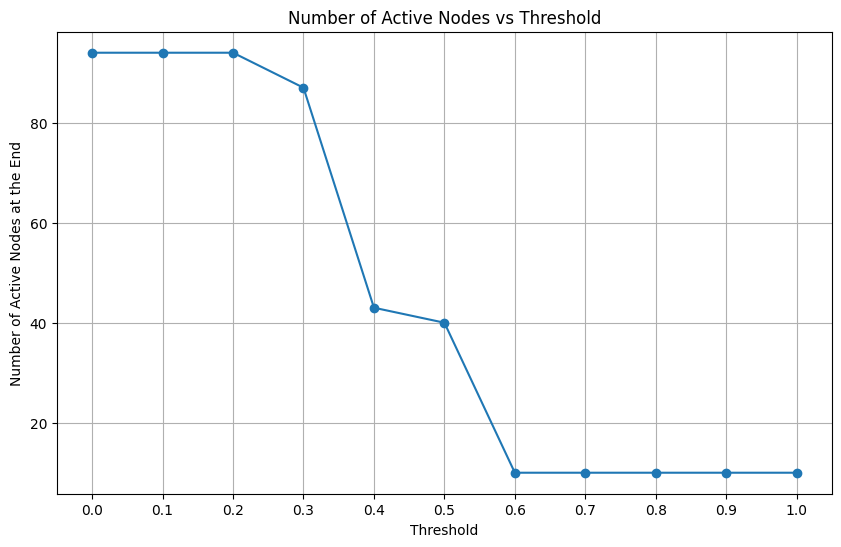


Dataframe of results for starting node 41:


,threshold,final_active_labels,final_unactive_labels
0,0.0,"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU...",[]
1,0.1,"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU...",[]
2,0.2,"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU...",[]
3,0.3,"[GIRL, OLDER BOY #1, OLDER BOY #2, JENNY, JENN...","[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."
4,0.4,"[GIRL, OLDER BOY #1, OLDER BOY #2, JENNY, JENN...","[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."
5,0.5,"[GIRL, OLDER BOY #1, OLDER BOY #2, JENNY, JENN...","[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."
6,0.6,"[JENNY, CAB DRIVER]","[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."
7,0.7,"[JENNY, CAB DRIVER]","[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."
8,0.8,"[JENNY, CAB DRIVER]","[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."
9,0.9,"[JENNY, CAB DRIVER]","[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."


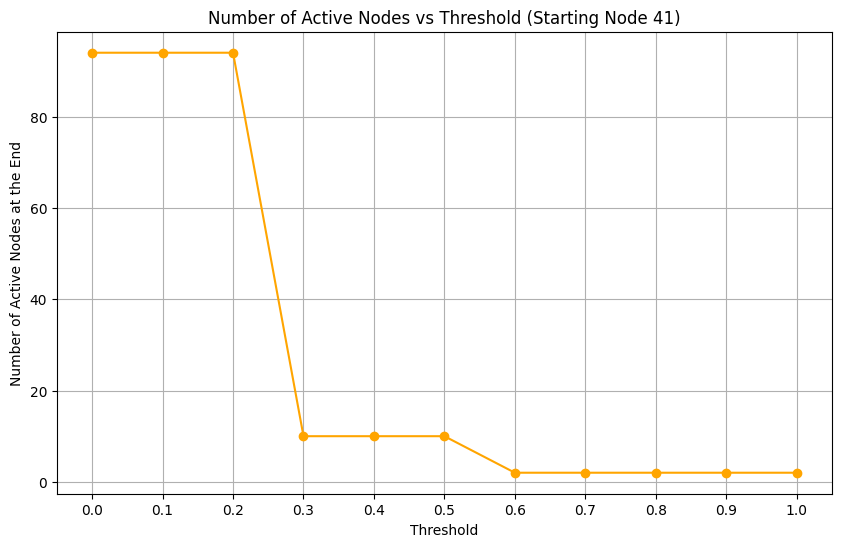


Dataframe of results for starting node 48:


,threshold,final_active_labels,final_unactive_labels
0,0.0,"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU...",[]
1,0.1,"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU...",[]
2,0.2,"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU...",[]
3,0.3,"[ANCHORMAN, BOB HOPE, PRESIDENT JOHNSON, LT DA...","[ABBIE HOFFMAN, AGING HIPPIE, ANNOUNCER, ANOTH..."
4,0.4,"[ANCHORMAN, BOB HOPE, PRESIDENT JOHNSON, LT DA...","[ABBIE HOFFMAN, AGING HIPPIE, ANNOUNCER, ANOTH..."
5,0.5,"[LT DAN, MARGO, BOB HOPE]","[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."
6,0.6,[LT DAN],"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."
7,0.7,[LT DAN],"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."
8,0.8,[LT DAN],"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."
9,0.9,[LT DAN],"[ABBIE HOFFMAN, AGING HIPPIE, ANCHORMAN, ANNOU..."


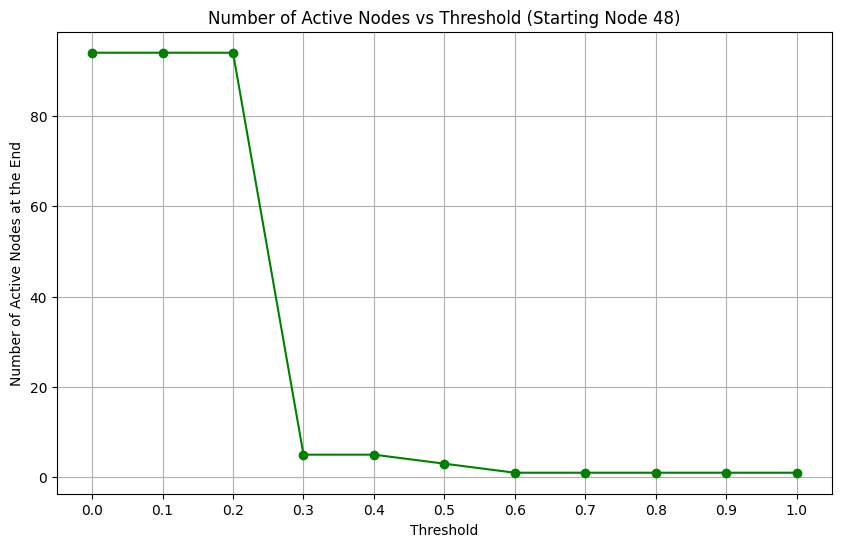

In [ ]:
# Different outbreak scenarios
scenarios = [
    {"origin": [35], "threshold": 0.3, "label": "Forrest, low threshold"},
    {"origin": [35], "threshold": 0.5, "label": "Forrest, medium threshold"},
    {"origin": [35], "threshold": 0.7, "label": "Forrest, high threshold"},
    {"origin": [41], "threshold": 0.5, "label": "Jenny, medium threshold"},
    {"origin": [48], "threshold": 0.5, "label": "Lt. Dan, medium threshold"},
    {"origin": [35, 41], "threshold": 0.5, "label": "Forrest + Jenny, medium threshold"},
]

scenario_results = []

for scenario in scenarios:
    final_active = random_weighted_fractional_threshold_model(
        G,
        initial_active=scenario["origin"],
        threshold=scenario["threshold"]
    )

    scenario_results.append({
        "scenario": scenario["label"],
        "origin": scenario["origin"],
        "threshold": scenario["threshold"],
        "final_active_nodes": len(final_active),
        "outbreak_share": len(final_active) / G.number_of_nodes()
    })

scenario_results_df = pd.DataFrame(scenario_results)
display(scenario_results_df)
#lets how much lowering the threshold by 0.1 changes the final active nodes and make a line graph of the number of active nodes at the end of the process for each threshold value, and print the labels of active and unactive nodes at the end of the process for each threshold value, and if all nodes are active, print "All nodes are active."
#pandas dataframe with columns "threshold", "final_active_labels", "final_unactive_labels"
dataframe = []
thresholds = [i * 0.1 for i in range(0, 11)]
initial_active = [35]
for threshold in thresholds:
    final_active = random_weighted_fractional_threshold_model(G, initial_active, threshold)
    final_active_labels = [nodes_df.loc[nodes_df['# index'] == node, 'label'].values[0] for node in final_active]
    final_unactive = set(G.nodes()) - final_active
    final_unactive_labels = [nodes_df.loc[nodes_df['# index'] == node, 'label'].values[0] for node in final_unactive]
    dataframe.append({
        "threshold": threshold,
        "final_active_labels": final_active_labels,
        "final_unactive_labels": final_unactive_labels
    })


df = pd.DataFrame(dataframe)

print("\nDataframe of results for starting node 35:")
display(df)


#line graph of the number of active nodes at the end of the process for each threshold value
thresholds = [i * 0.1 for i in range(0, 11)]
active_counts = []
for threshold in thresholds:
    final_active = random_weighted_fractional_threshold_model(G, initial_active, threshold)
    active_counts.append(len(final_active))
plt.figure(figsize=(10, 6))
plt.plot(thresholds, active_counts, marker='o')
plt.title('Number of Active Nodes vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Number of Active Nodes at the End')
plt.xticks(thresholds)
plt.grid()
plt.show()

#lets calculate the same for starting node 36
initial_active = [41]
dataframe_41 = []
for threshold in thresholds:
    final_active = random_weighted_fractional_threshold_model(G, initial_active, threshold)
    final_active_labels = [nodes_df.loc[nodes_df['# index'] == node, 'label'].values[0] for node in final_active]
    final_unactive = set(G.nodes()) - final_active
    final_unactive_labels = [nodes_df.loc[nodes_df['# index'] == node, 'label'].values[0] for node in final_unactive]
    dataframe_41.append({
        "threshold": threshold,
        "final_active_labels": final_active_labels,
        "final_unactive_labels": final_unactive_labels
    })


df_41 = pd.DataFrame(dataframe_41)
print("\nDataframe of results for starting node 41:")
display(df_41)


#graph of the number of active nodes at the end of the process for each threshold value for starting node 36
active_counts_41 = []
for threshold in thresholds:
    final_active = random_weighted_fractional_threshold_model(G, initial_active, threshold)
    active_counts_41.append(len(final_active))
plt.figure(figsize=(10, 6))
plt.plot(thresholds, active_counts_41, marker='o', color='orange')
plt.title('Number of Active Nodes vs Threshold (Starting Node 41)')
plt.xlabel('Threshold')
plt.ylabel('Number of Active Nodes at the End')
plt.xticks(thresholds)
plt.grid()
plt.show()


#now for 48
initial_active = [48]
dataframe_48 = []
for threshold in thresholds:
    final_active = random_weighted_fractional_threshold_model(G, initial_active, threshold)
    final_active_labels = [nodes_df.loc[nodes_df['# index'] == node, 'label'].values[0] for node in final_active]
    final_unactive = set(G.nodes()) - final_active
    final_unactive_labels = [nodes_df.loc[nodes_df['# index'] == node, 'label'].values[0] for node in final_unactive]
    dataframe_48.append({
        "threshold": threshold,
        "final_active_labels": final_active_labels,
        "final_unactive_labels": final_unactive_labels
    })

df_48 = pd.DataFrame(dataframe_48)
print("\nDataframe of results for starting node 48:")
display(df_48)
#graph of the number of active nodes at the end of the process for each threshold value for starting node 63
active_counts_48 = []
for threshold in thresholds:
    final_active = random_weighted_fractional_threshold_model(G, initial_active, threshold)
    active_counts_48.append(len(final_active))
plt.figure(figsize=(10, 6))
plt.plot(thresholds, active_counts_48, marker='o', color='green')
plt.title('Number of Active Nodes vs Threshold (Starting Node 48)')
plt.xlabel('Threshold')
plt.ylabel('Number of Active Nodes at the End')
plt.xticks(thresholds)
plt.grid()
plt.show()

The results show how diffusion depends strongly on both the starting node and the threshold parameter. When Forrest is the initial active node, the outbreak is larger because Forrest is the main hub of the network and is connected to many different parts of the story. Lower thresholds generate wider cascades, while higher thresholds make diffusion more difficult because nodes require a stronger fraction of active neighbors before becoming active. The only node which shows a pretty good resistance to the threshold increase is Forest due to its obvious centrality in the plot and its interaction with many characters like Mrs Blue or Kennedy which have him as their only link. Starting from Jenny or Lt. Dan usually produces smaller outbreaks, showing that they are important characters but less structurally central than Forrest. The scenario with both Forrest and Jenny as initial active nodes produces a stronger cascade because it activates two highly relevant parts of the character network at the same time.

## CONCLUSION

The character network of Forrest Gump presents a centralized structure. The network has a low density (0.062). Our attempts to model this using a preferential attachment model showed that we can replicate the size and average degree, but the real network has higher local cohesion compared to that of synthetic models. This reflects episodic structure of the narrative.
The network shows the presence of local cliques. The manual clustering analysis yielded a high average coefficient (0.80), showing that a character’s acquaintances are likely to know each other. On the other hand, the CCDF analysis revealed that high node clustering is significantly more frequent than high average neighbor clustering. This suggests that clusters of characters are usually separated from the rest of the network's neighbors.
Forrest has a high betweenness centrality (around 0.8) and closeness centrality (around 0.9). This confirms that he is the most connected character and the primary bridge between other nodes. Other important characters (Jenny and Lt. Dan) also show high betweenness since they act as bridges between Forrest's different stages of life. The relationship between these characters evolves and persists over the decades.
Thanks to bridge removal we identified 35 communities. This community count reflects the film's self-contained episodic structure. Characters in one part of Forrest's life are highly connected among each other but they rarely interact with characters in other parts of his life.
Overall, the graph is highly influenced by the narrative: the main character is constantly present while the world changes around him.